In [1]:
#to be run on deafultinterpreter 3.12.8 in \documents\venvs\py312\Scripts\python.exe
import nidaqmx
import nidaqmx.system
import matplotlib.pyplot as plt
import numpy as np
import time

from nidaqmx.constants import AcquisitionType

system = nidaqmx.system.System.local()
for device in system.devices:
    print(device)

Device(name=Dev1)


In [61]:

import nidaqmx as nd
import matplotlib.pyplot as plt
import numpy as np
import time

from nidaqmx.constants import AcquisitionType, Edge, TerminalConfiguration, Coupling, DigitalPatternCondition
from nidaqmx.constants import DigitalWidthUnits, Slope, Timescale, TriggerType, WindowTriggerCondition1

sample_rate = 500_000 #Hz
samples = 500 #to modify the total acquisition time, change this keeping in mind that samples/sample_rate = acquisition time in seconds
num_secs = 1
data_bulk = []

with nd.Task() as task:
    #task.ai_channels.add_ai_voltage_chan("/Dev1/ai0")
    task.ai_channels.add_ai_voltage_chan("Dev1/ai0", terminal_config=TerminalConfiguration.DIFF)

    #timing part
    task.timing.cfg_samp_clk_timing(sample_rate, sample_mode = AcquisitionType.FINITE, 
                                    samps_per_chan = samples) 
    
    #external clock timing, possibly wrong method
    #task.timing.cfg_samp_clk_timing(rate=sample_rate, source="/Dev1/PFI7", active_edge=Edge.RISING, 
    #                                sample_mode=AcquisitionType.FINITE, samps_per_chan=samples)
    
    #External Triggering: start the acquisition only after a digital edge arrives on the chosen PFI line
    #task.triggers.start_trigger.cfg_dig_edge_start_trig(trigger_source="/Dev1/PFI0", trigger_edge=Edge.RISING)
    #analog window triggering 
    task.triggers.start_trigger.cfg_anlg_window_start_trig(4, 2, trigger_source="/Dev1/APFI0", trigger_when=WindowTriggerCondition1.ENTERING_WINDOW)

    """
    # DAQmx Start Code
    task.start()
    for i in range(1, int(num_secs*sample_rate/samples)+1):
        # DAQmx Read Code
        data_sec = task.read(samples)
        #print(data_sec)
        # Append data
        data_bulk.append(data_sec)
    """
    task.start()
    data_sec = task.read(samples)
    data_bulk.append(data_sec)
    # DAQmx Stop task
    task.stop()

meas_data = np.array(data_bulk)

t = np.arange(meas_data.size)/sample_rate 
plt.plot(t, meas_data.flatten())
print(meas_data.flatten()[-1])
plt.ylabel('Voltage [V]')
plt.xlabel('Time [sec]')
#plt.xticks(ticks=np.arange(0, t[-1]+0.25, 0.25))
plt.xticks(ticks=np.arange(0, t[-1]+0.00001))
plt.show()

#outfile = "meas_data"
#np.save(outfile, meas_data)

DaqError: The specified resource is reserved. The operation could not be completed as specified.

Task Name: _unnamedTask<38>

Status Code: -50103

Acquisition started - press Ctrl+C to stop
KeyboardInterrupt received — stopping
Acquired 1692000 samples in 3.70 s
Saved thresholded data to measured_data_thresholded.csv


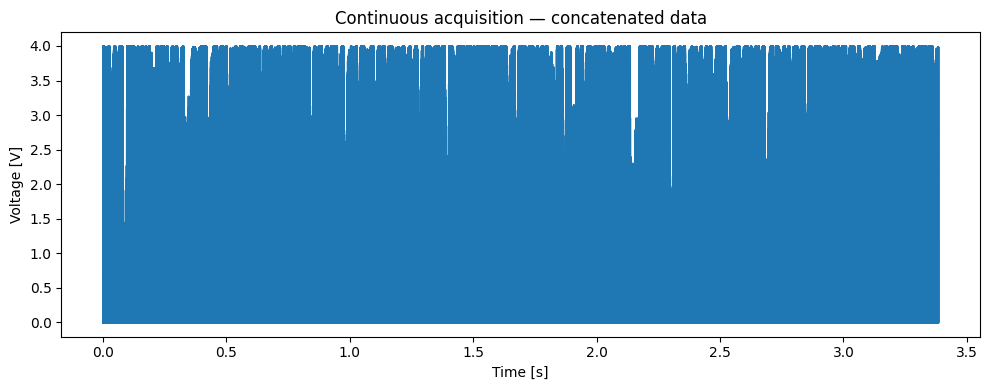

In [51]:
# Continuous acquisition: accumulate chunks and create a single array at the end
import nidaqmx as nd
from nidaqmx.constants import AcquisitionType, TerminalConfiguration
import numpy as np
import matplotlib.pyplot as plt
import time

# Increase sample rate to resolve narrower features, and read smaller chunks more often.
# Keep read_size comfortably below the buffer size so the loop can service the task quickly.
sample_rate = 500_000
buffer_size = 50_000   # internal buffer size (samps per channel)
read_size = 1_000      # samples read per loop iteration

data_chunks = []
start_ts = time.time()
with nd.Task() as task:
    task.ai_channels.add_ai_voltage_chan("Dev1/ai0", terminal_config=TerminalConfiguration.DIFF)
    task.timing.cfg_samp_clk_timing(sample_rate, sample_mode=AcquisitionType.CONTINUOUS, samps_per_chan=buffer_size)
    task.triggers.start_trigger.cfg_anlg_window_start_trig(4, 2, trigger_source="/Dev1/APFI0", trigger_when=WindowTriggerCondition1.ENTERING_WINDOW)

    task.start()
    print('Acquisition started - press Ctrl+C to stop')
    try:
        while True:
            chunk = np.asarray(task.read(read_size), dtype=float)
            data_chunks.append(chunk)
    except KeyboardInterrupt:
        print('KeyboardInterrupt received — stopping')
    finally:
        task.stop()

# Concatenate into a single 1D array
if data_chunks:
    data = np.concatenate(data_chunks)
    total_time = time.time() - start_ts
    print(f'Acquired {data.size} samples in {total_time:.2f} s')
    threshold_v = 1.0
    thresholded = np.where(data >= threshold_v, data, 0.0)
    compressed = []
    last_was_zero = False
    for value in thresholded:
        if value == 0.0:
            if not last_was_zero:
                compressed.append(0.0)
                last_was_zero = True
        else:
            compressed.append(float(value))
            last_was_zero = False
    data_column = np.asarray(compressed).reshape(-1, 1)
    output_file = 'measured_data_thresholded.csv'
    np.savetxt(output_file, data_column, delimiter=',', header='voltage_V', comments='')
    print(f'Saved thresholded data to {output_file}')
    t = np.arange(data.size) / sample_rate
    plt.figure(figsize=(10,4))
    plt.plot(t, data)
    plt.xlabel('Time [s]')
    plt.ylabel('Voltage [V]')
    plt.title('Continuous acquisition — concatenated data')
    plt.tight_layout()
    plt.show()
else:
    print('No data acquired')


Armed, waiting for trigger #1...
Acquisition 1 complete
Armed, waiting for trigger #2...
Acquisition 2 complete
Armed, waiting for trigger #3...
Acquisition 3 complete
Armed, waiting for trigger #4...
Acquisition 4 complete
Armed, waiting for trigger #5...
Acquisition 5 complete
Armed, waiting for trigger #6...
Acquisition 6 complete
Armed, waiting for trigger #7...
Acquisition 7 complete
Armed, waiting for trigger #8...
Acquisition 8 complete
Armed, waiting for trigger #9...
Acquisition 9 complete
Armed, waiting for trigger #10...
Acquisition 10 complete


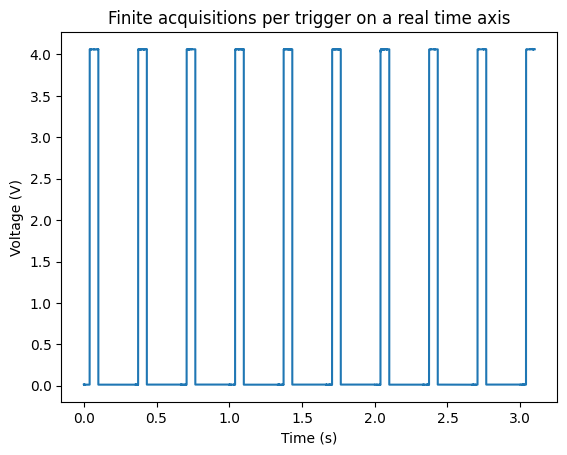

In [7]:
# Finite-per-trigger acquisition: one finite capture per rising edge, plotted on a real time axis
import nidaqmx
from nidaqmx.constants import AcquisitionType, Edge, TerminalConfiguration
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 10_000
samples = 1_000
trigger_rate_hz = 3.0
max_acqs = 10  # set to None for indefinite acquisitions. #each acquisition takes nr of samples as set in samples
#the total acquisition in sec will be ( samples * max_acqs * trigger_rate ) / sample_rate

capture_duration_s = samples / sample_rate
trigger_period_s = 1.0 / trigger_rate_hz
gap_between_acqs_s = max(trigger_period_s - capture_duration_s, 0.0)

all_times = []
all_values = []
current_time_s = 0.0
acq = 0

try:
    while max_acqs is None or acq < max_acqs:
        with nidaqmx.Task() as task:
            task.ai_channels.add_ai_voltage_chan("Dev1/ai0", terminal_config=TerminalConfiguration.DIFF)
            task.timing.cfg_samp_clk_timing(
                sample_rate,
                sample_mode=AcquisitionType.FINITE,
                samps_per_chan=samples,
            )
            task.triggers.start_trigger.cfg_dig_edge_start_trig(
                trigger_source="/Dev1/PFI0",
                trigger_edge=Edge.RISING,
            )

            print(f"Armed, waiting for trigger #{acq + 1}...")
            task.start()

            data = np.asarray(task.read(samples), dtype=float)
            time_axis = current_time_s + np.arange(data.size) / sample_rate
            all_times.append(time_axis)
            all_values.append(data)
            print(f"Acquisition {acq + 1} complete")

        acq += 1
        current_time_s += capture_duration_s + gap_between_acqs_s
except KeyboardInterrupt:
    print("Interrupted by user")

if all_times:
    plot_time = np.concatenate(all_times)
    plot_values = np.concatenate(all_values)
    plt.step(plot_time, plot_values)
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.title('Finite acquisitions per trigger on a real time axis')
    plt.show()
else:
    print('No acquisitions recorded')